# create a .topo file for a kegg pathway
select a kegg id (e.g. with help of the ipynb 1 and 2.) From this id a .topo file and an edge_index.pt will be created that can later be used as a graph prior for our ml pipeline.

Additionally gene_to_idx.pkl will be created that stores the mapping between L1000 gene identifiers and our own ids

In [1]:
pathway_id = "hsa04210"
pathway_name = "apoptosis"
# whether to treat the graph as undirected when creating the edge index file
to_undirected = False

In [2]:
from Bio.KEGG.KGML import KGML_parser
from Bio.KEGG import REST
from io import StringIO
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import torch
import os

In [3]:
def download_pathway(pathway_id):
    kgml = REST.kegg_get(pathway_id, "kgml").read()
    return KGML_parser.read(StringIO(kgml))

In [4]:
def kegg_to_L1000():
    """
    Fetch gene symbols for a list of KEGG gene IDs.
    """
    df_gene_info = pd.read_csv('data_phase1/gene_info.txt', sep='\t')  
    # create a map by using the columns 'gene_id' and 'gene_symbol'
    L1000_gene_map = df_gene_info.set_index('pr_gene_id')['pr_gene_symbol'].to_dict()
    # to every gene_id in the mapping add "hsa:" as a prefix
    L1000_gene_map = {f"hsa:{k}": v for k, v in L1000_gene_map.items()}
    return L1000_gene_map

In [5]:
pathway = download_pathway(pathway_id)

In [6]:
kegg_to_L1000_map = kegg_to_L1000()

In [7]:
activation = ["activation", "expression"]
inhibition = ["inhibition", "repression"]
other = ["compound", "hidden compound", "indirect effect", "state change", "binding/association", 
         "dissociation", "missing interaction", "phosphorylation", "dephosphorylation", "glycosylation", 
         "ubiquitination", "methylation"]

G = nx.DiGraph()
# A single KEGG pathway entry (node) can correspond to multiple gene IDs (e.g., family members); keep a list per node ID.
node_id_to_gene_ids = {}      # maps KEGG node ID to list of gene IDs (e.g. ['hsa:7157', 'hsa:1029'])

added_genes = 0
skipped_entirely = 0

# Add gene nodes
# KEGG encodes a "gene" entry that can be a set of genes; split and map each gene ID individually.
for node in pathway.genes:
    kegg_gene_ids = node.name.split()
    for kegg_gene_id in kegg_gene_ids:
        if kegg_gene_id not in kegg_to_L1000_map:
            continue
        else:
            G.add_node(kegg_gene_id, label=kegg_to_L1000_map[kegg_gene_id], type="gene")
            added_genes += 1
    # Store only the gene IDs that could be mapped; a KEGG node may map to multiple L1000 genes.
    node_id_to_gene_ids[node.id] = [gid for gid in kegg_gene_ids if gid in kegg_to_L1000_map]

print(node_id_to_gene_ids)

print(f"✅ Added {added_genes} Genes to the graph.")

# Add edges based on relations

activating_edges = 0
inhibiting_edges = 0
skipped_edges = 0

for rel in pathway.relations:
    src_id = rel.entry1.id
    tgt_id = rel.entry2.id

    # Only add edge if both sides are gene-type nodes
    if src_id in node_id_to_gene_ids and tgt_id in node_id_to_gene_ids:
        src_genes = node_id_to_gene_ids[src_id]
        tgt_genes = node_id_to_gene_ids[tgt_id]

        for subtype in rel.subtypes:
            interaction = subtype[0]
            # Determine the type of interaction based on the subtype
            if interaction in activation:
                interaction = "1"
                activating_edges += len(src_genes) * len(tgt_genes)
            elif interaction in inhibition:
                interaction = "2"
                inhibiting_edges += len(src_genes) * len(tgt_genes)
            elif interaction in other:
                interaction = "3"
                skipped_edges += len(src_genes) * len(tgt_genes)
                continue
            else:
                "⚠️ Unknown interaction type: {interaction} (subtype: {subtype})"

            # Connect each source gene to each target gene
            for src_gene in src_genes:
                for tgt_gene in tgt_genes:
                    G.add_edge(src_gene, tgt_gene, interaction=interaction)

    
G = nx.relabel_nodes(G, {node: G.nodes[node]["label"] for node in G.nodes() if "label" in G.nodes[node]})

print(f"✅ Added {G.number_of_edges()} edges to the graph.")
print(f"✅ {activating_edges} activating edges, {inhibiting_edges} inhibiting edges, "
    f"{skipped_edges} skipped edges due to unknown interaction types.")

# remove isolated nodes
G.remove_nodes_from(list(nx.isolates(G)))
print(f"✅ Removed isolated nodes. Graph now has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

wcc = list(nx.weakly_connected_components(G))
print(f"✅ Graph has {len(wcc)} weakly connected components.")
wcc_sizes = [len(c) for c in wcc]
print(f"✅ Sizes of weakly connected components: {wcc_sizes}")

# choose largest weakly connected component
largest_wcc = max(wcc, key=len)
G = G.subgraph(largest_wcc).copy()
print(f"✅ Selected largest weakly connected component. Graph now has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")



{10: ['hsa:598'], 11: ['hsa:1676'], 12: ['hsa:472'], 13: ['hsa:7157'], 14: ['hsa:2021'], 15: ['hsa:9131'], 16: ['hsa:596'], 17: ['hsa:329', 'hsa:330', 'hsa:331', 'hsa:332'], 18: ['hsa:1677'], 19: ['hsa:842'], 20: ['hsa:840'], 21: ['hsa:836'], 22: ['hsa:572'], 23: ['hsa:4790', 'hsa:5970'], 24: ['hsa:329', 'hsa:330', 'hsa:331', 'hsa:332'], 25: ['hsa:839'], 26: ['hsa:4792'], 27: ['hsa:317'], 28: ['hsa:54205'], 29: ['hsa:637'], 30: ['hsa:841'], 31: ['hsa:843'], 32: ['hsa:823', 'hsa:824'], 33: ['hsa:10000', 'hsa:207', 'hsa:208'], 34: [], 35: ['hsa:1147', 'hsa:3551', 'hsa:8517'], 36: ['hsa:8837'], 37: ['hsa:5290', 'hsa:5291', 'hsa:5293', 'hsa:5295', 'hsa:5296', 'hsa:8503'], 38: ['hsa:7186'], 39: ['hsa:8737'], 40: ['hsa:8717'], 41: ['hsa:8772'], 42: ['hsa:8717'], 43: ['hsa:8772'], 44: ['hsa:1439', 'hsa:3563'], 45: ['hsa:4914'], 46: ['hsa:7132'], 47: ['hsa:8795'], 48: ['hsa:355'], 49: ['hsa:3562'], 50: ['hsa:4803'], 51: ['hsa:7124'], 53: ['hsa:8743'], 54: ['hsa:356'], 102: ['hsa:6709'], 103: [

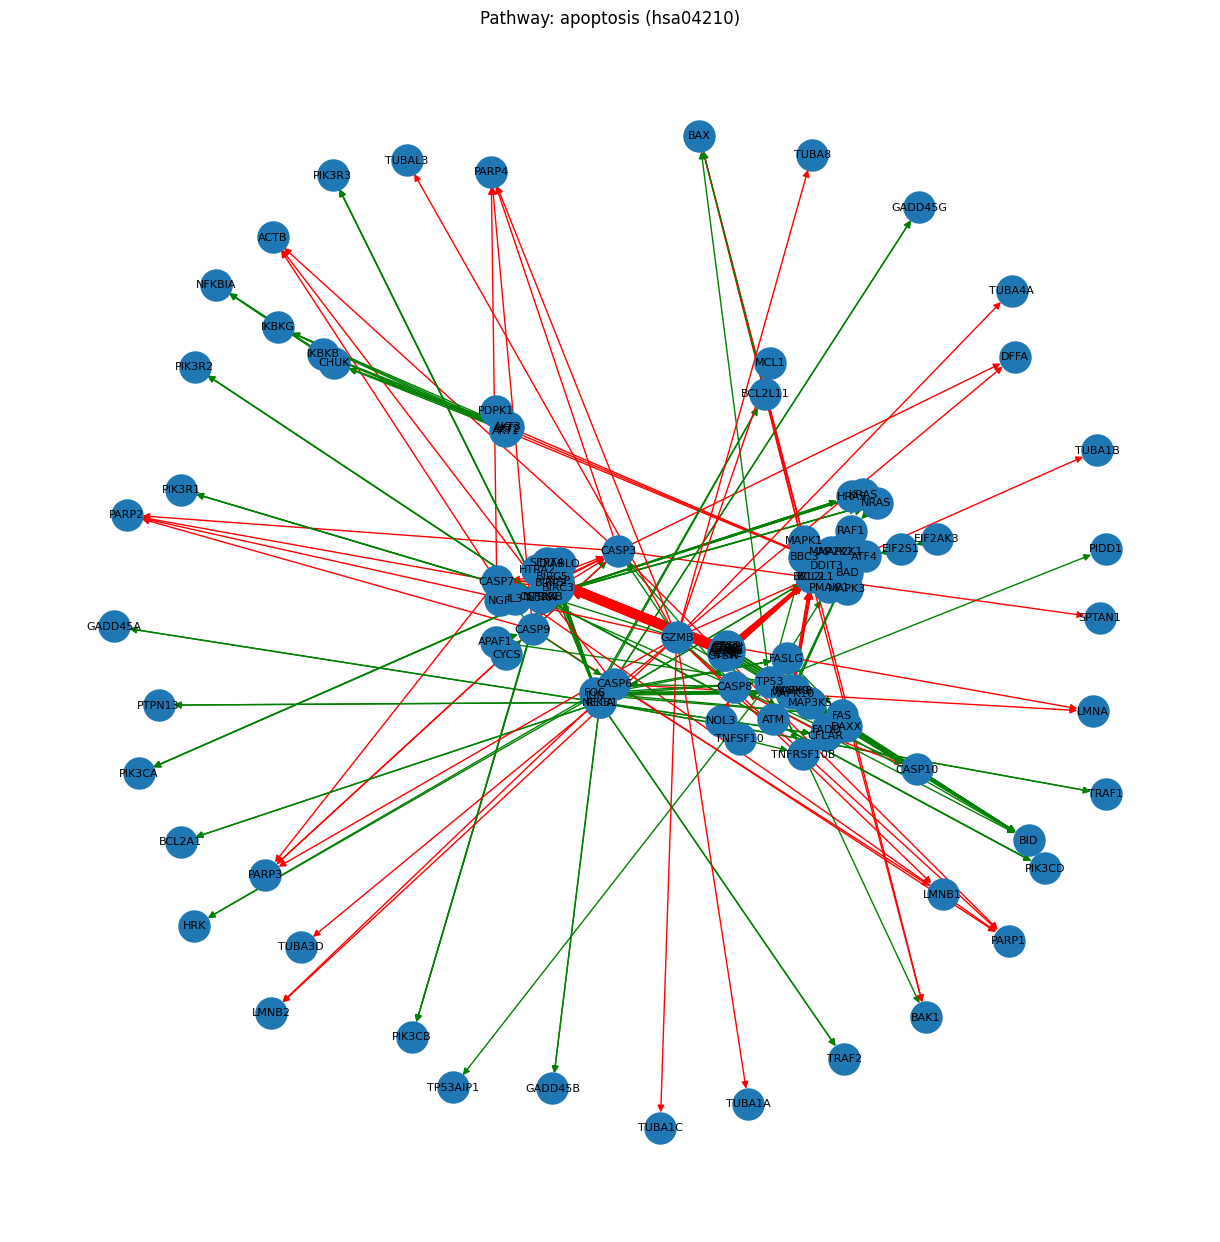

In [8]:
# plot the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)
edge_colors = []
for u, v in G.edges():
    interaction = G[u][v]['interaction']
    if interaction == "1":
        edge_colors.append('green')
    elif interaction == "2":
        edge_colors.append('red')
    else:
        edge_colors.append('gray')
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, edge_color=edge_colors)
plt.title(f"Pathway: {pathway_name} ({pathway_id})")
plt.show()

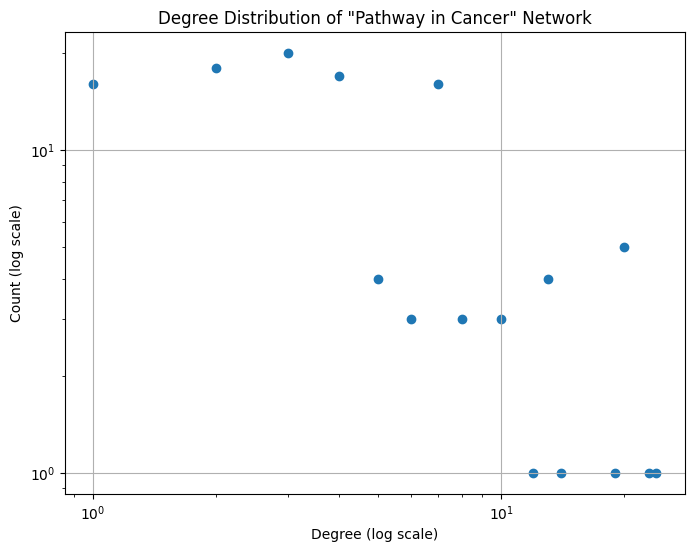

In [9]:
# prot degree distribution in log log scale with degree on x axis and count on y axis. make one dot per degree value
degrees = [G.degree(n) for n in G.nodes()]
degree_counts = pd.Series(degrees).value_counts().sort_index()
plt.figure(figsize=(8,6))
plt.scatter(degree_counts.index, degree_counts.values)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Degree Distribution of "Pathway in Cancer" Network')
plt.grid(True)
plt.show()

In [10]:
def create_topo_file_from_graph(network_name, G: nx.DiGraph, dir):
    """
    Create a topo file as expected by racipe from a nx Graph
    and store it in the const.TOPO_PATH directory.
    :param G: nx Graph
    """
    new_file_path = Path(dir) / f"{network_name}.topo" 
    # save graph to a trrust.topo file with the header Source Target Type
    with open(new_file_path, "w") as f:
        f.write("Source Target Type\n")
        for u, v, d in G.edges(data='interaction'):
            f.write(f"{u} {v} {d}\n")
    print(f"✅ Saved topo file for graph with {G.number_of_edges()} edges  and {G.number_of_nodes()} nodes to {new_file_path}")

create_topo_file_from_graph(pathway_name, G, "experiment_data")

✅ Saved topo file for graph with 314 edges  and 114 nodes to experiment_data/apoptosis.topo


In [11]:
# L1000 to id
L1000_to_idx_map = {gene: idx for idx, gene in enumerate(G.nodes())}

In [12]:
# Convert to undirected if requested (common for GNNs)
if to_undirected:
    G = G.to_undirected()

# Create edge_index tensor
edges = list(G.edges())
edge_list = [(L1000_to_idx_map[u], L1000_to_idx_map[v]) for u, v in edges]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
# store edge_index as a torch file
torch.save(edge_index, f"experiment_data/{pathway_name}_edge_index.pt")
print(f"✅ Saved edge_index tensor with shape {edge_index.shape} to experiment_data/{pathway_name}_edge_index.pt")

✅ Saved edge_index tensor with shape torch.Size([2, 314]) to experiment_data/apoptosis_edge_index.pt


In [13]:
# store L1000_to_idx_map as gene_to_idx.pkl
import pickle
with open(f"experiment_data/l1000_to_idx.pkl", "wb") as f:
    pickle.dump(L1000_to_idx_map, f)
print(f"✅ Saved gene to index mapping to experiment_data/l1000_to_idx.pkl")
with open(f"experiment_data/kegg_to_L1000_map.pkl", "wb") as f:
    # from the keys of kegg_to_L1000_map cut the "hsa:" prefix
    kegg_to_L1000_map_no_prefix = {k.split("hsa:")[-1]: v for k, v in kegg_to_L1000_map.items()}
    pickle.dump(kegg_to_L1000_map_no_prefix, f)
print(f"✅ Saved gene to index mapping to experiment_data/kegg_to_L1000_map.pkl")


✅ Saved gene to index mapping to experiment_data/l1000_to_idx.pkl
✅ Saved gene to index mapping to experiment_data/kegg_to_L1000_map.pkl
